# Import libraries

In [5]:
pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 1.8 MB/s eta 0:00:05
   ------ --------------------------------- 1.3/8.1 MB 2.0 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.1 MB 2.8 MB/s eta 0:00:03
   -------------------- ------------------- 4.2/8.1 MB 4.3 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 6.5 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 6.6 MB/s  0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ---- ---------

In [1]:
import itertools
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Read the data

In [7]:
%pwd

'c:\\Users\\shamr\\OneDrive\\Desktop\\Fake-News-Detection\\server'

In [11]:
news_df = pd.read_csv("data/news.csv")
news_df.shape

(6335, 4)

The dataset has 6335 rows and 4 columns

In [12]:
news_df.head()

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


# Split the news and the labels

In [13]:
labels = news_df.label.copy()
news = news_df.text.copy()

In [15]:
labels.info()

<class 'pandas.Series'>
RangeIndex: 6335 entries, 0 to 6334
Series name: label
Non-Null Count  Dtype
--------------  -----
6335 non-null   str  
dtypes: str(1)
memory usage: 49.6 KB


In [16]:
news.tail()

6330    The State Department told the Republican Natio...
6331    The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...
6332     Anti-Trump Protesters Are Tools of the Oligar...
6333    ADDIS ABABA, Ethiopia —President Obama convene...
6334    Jeb Bush Is Suddenly Attacking Trump. Here's W...
Name: text, dtype: str

# Initialize the tf-idf vectorizer

In [17]:
tfidf_vec = TfidfVectorizer(stop_words='english', max_df=0.7)

# Fit the vectorizer to the data

In [18]:
news = tfidf_vec.fit_transform(news)

In [21]:
news

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1665262 stored elements and shape (6335, 67351)>

# Split the training and testing data

In [22]:
x_train, x_test, y_train, y_test = train_test_split(news, labels, test_size=0.2, random_state=42, stratify=labels)

In [24]:
x_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1343980 stored elements and shape (5068, 67351)>

In [25]:
x_test

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 321282 stored elements and shape (1267, 67351)>

# Initialize a PassiveAggressiveClassifier

In [27]:
pac = PassiveAggressiveClassifier()

c:\Users\shamr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


# Fit the classifier to the training data

In [28]:
pac.fit(x_train, y_train)

,"C C: float, default=1.0Aggressiveness parameter for the passive-agressive algorithm, see [1].For PA-I it is the maximum step size. For PA-II it regularizes thestep size (the smaller `C` the more it regularizes).As a general rule-of-thumb, `C` should be small when the data is noisy.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`~sklearn.linear_model.PassiveAggressiveClassifier.partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically set asidea stratified fraction of training data as validation and terminatetraining when validation score is not improving by at least `tol` for`n_iter_no_change` consecutive epochs... versionadded:: 0.20",False
,"validation_fraction validation_fraction: float, default=0.1The proportion of training data to set aside as validation set forearly stopping. Must be between 0 and 1.Only used if early_stopping is True... versionadded:: 0.20",0.1
,"n_iter_no_change n_iter_no_change: int, default=5Number of iterations with no improvement to wait before early stopping... versionadded:: 0.20",5
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"loss loss: str, default=""hinge""The loss function to be used:hinge: equivalent to PA-I in the reference paper.squared_hinge: equivalent to PA-II in the reference paper.",'hinge'
,"n_jobs n_jobs: int or None, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


# Predict the labels of the test data

In [29]:
y_pred = pac.predict(x_test)

# Evaluation

In [30]:
score = accuracy_score(y_test, y_pred)

In [35]:
score

0.9439621152328335

In [31]:
confusion_matrix(y_test, y_pred, labels=['FAKE', 'REAL'])

array([[603,  30],
       [ 39, 595]])

In [33]:
pip install matplotlib

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 752.9 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/8.3 MB 747.0 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/8.3 MB 747.0 kB/s eta 0:00:11
   ----- ---------------------------------- 1.0/8.3 MB 774.8 kB/s eta 0:00:10
   ------ --------------------------------- 1.3/8.3 MB 805.0 kB/s eta 0:00:09
   ------- -------------------------------- 1.6/8.3 MB 826.6 kB/s eta 0:00:09
   ------- -------------------------------- 1.6/8.3 MB 826.6 kB/s eta 0:00:09
   -------- ------------------------------- 1.8/8.3 MB 850.3 kB/s eta 0:00:08
   ---------- -----------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Matplotlib is building the font cache; this may take a moment.


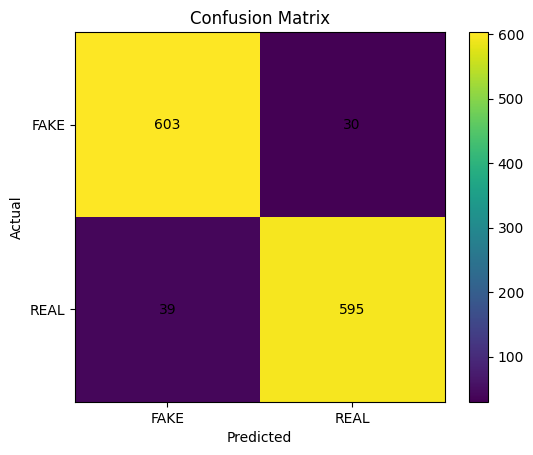

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['FAKE', 'REAL'])

# Plot
plt.figure()
plt.imshow(cm)

# Labels
classes = ['FAKE', 'REAL']
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

# Axis labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

# Show values inside boxes
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()